In [1]:
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import load_ticker

df = load_ticker("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(df.head())
print(df.shape)

Price            Close        High         Low        Open    Volume
Date                                                                
2020-01-01  675.324158  683.152852  673.490062  679.081936  14004468
2020-01-02  686.821228  689.348791  676.397899  676.397899  17710316
2020-01-03  687.648804  689.661895  681.318729  685.792252  20984698
2020-01-06  671.700623  683.510705  670.134872  679.976657  24519177
2020-01-07  682.034546  686.463335  677.068889  679.529321  16683622
(1486, 5)


In [2]:
print("Columns:", df.columns.tolist())
print("Index type:", type(df.index))
print("\nFirst row:")
print(df.iloc[0])

Columns: ['Close', 'High', 'Low', 'Open', 'Volume']
Index type: <class 'pandas.DatetimeIndex'>

First row:
Price
Close     6.753242e+02
High      6.831529e+02
Low       6.734901e+02
Open      6.790819e+02
Volume    1.400447e+07
Name: 2020-01-01 00:00:00, dtype: float64


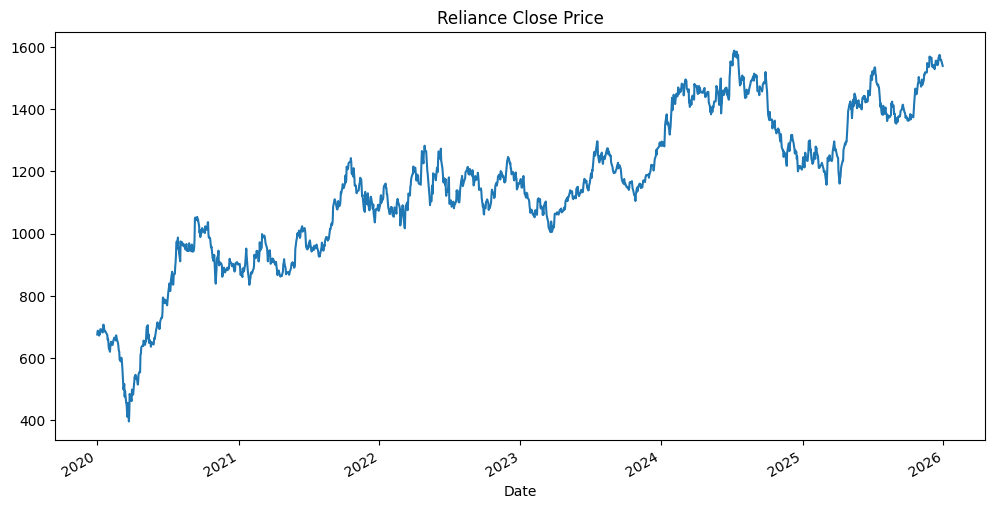

Missing values per column:
Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

Non-positive close prices: 0


In [3]:
# Plot the close price
import matplotlib.pyplot as plt

df["Close"].plot(figsize=(12, 6), title="Reliance Close Price")
plt.show()

# Are there any missing values?
print("Missing values per column:")
print(df.isnull().sum())

# Any zero or negative prices? (would be bad)
print("\nNon-positive close prices:", (df["Close"] <= 0).sum())

In [4]:
from backtester.data.loader import load_multiple_tickers

tickers = ["RELIANCE.NS", "TCS.NS", "INFY.NS"]
data = load_multiple_tickers(tickers, "2023-01-01", "2024-12-31")

print(f"Loaded {len(data)} stocks!")
print(data["TCS.NS"].head())

Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
Loaded 3 stocks!
Price             Close         High          Low         Open   Volume
Date                                                                   
2023-01-02  2932.793701  2937.649675  2909.188913  2932.389092   709547
2023-01-03  2977.665771  2985.444024  2918.271578  2924.296376  1245178
2023-01-04  2980.633057  2992.053455  2955.050003  2973.484221  1231668
2023-01-05  2977.440674  3001.000457  2951.227986  2994.615836  1826057
2023-01-06  2887.922607  2968.853320  2877.536455  2967.459470  2488376


In [5]:
#reading a parquet downloaded file, for  faster experience
import time
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import load_ticker_with_cache
# First time: downloads (slow)
start_time = time.time()
df1 = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(f"First load: {time.time() - start_time:.2f} seconds")

# Second time: from disk (fast)
start_time = time.time()
df2 = load_ticker_with_cache("RELIANCE.NS", "2020-01-01", "2025-12-31")
print(f"Second load: {time.time() - start_time:.2f} seconds")


Loading RELIANCE.NS from cache
First load: 0.00 seconds
Loading RELIANCE.NS from cache
Second load: 0.00 seconds


In [6]:
"""GETTING CLOSE PRICES IN A USEFUL SHAPE-->having a single DataFrame with all close prices of different stocks"""
import sys
sys.path.insert(0, "../src")
from backtester.data.loader import get_close_prices
from backtester.data.loader import load_multiple_tickers

data = load_multiple_tickers(["RELIANCE.NS", "TCS.NS", "INFY.NS"], "2022-01-01", "2024-12-31")
close_prices = get_close_prices(data)

print(close_prices.head())
print(f"\nShape: {close_prices.shape}")

Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
            RELIANCE.NS       TCS.NS      INFY.NS
Date                                             
2023-01-02  1175.889648  2932.793701  1397.702148
2023-01-03  1167.284546  2977.665771  1396.372437
2023-01-04  1149.709595  2980.633057  1370.921997
2023-01-05  1147.655396  2977.440674  1352.946167
2023-01-06  1158.086182  2887.922607  1328.458984

Shape: (490, 3)


In [7]:
"""HAD GOT A BUG HERE

The data was loading from previous Chache , and was very frustrating.
Claude helped me in debugging"""

'HAD GOT A BUG HERE\n\nThe data was loading from previous Chache , and was very frustrating.\nClaude helped me in debugging'

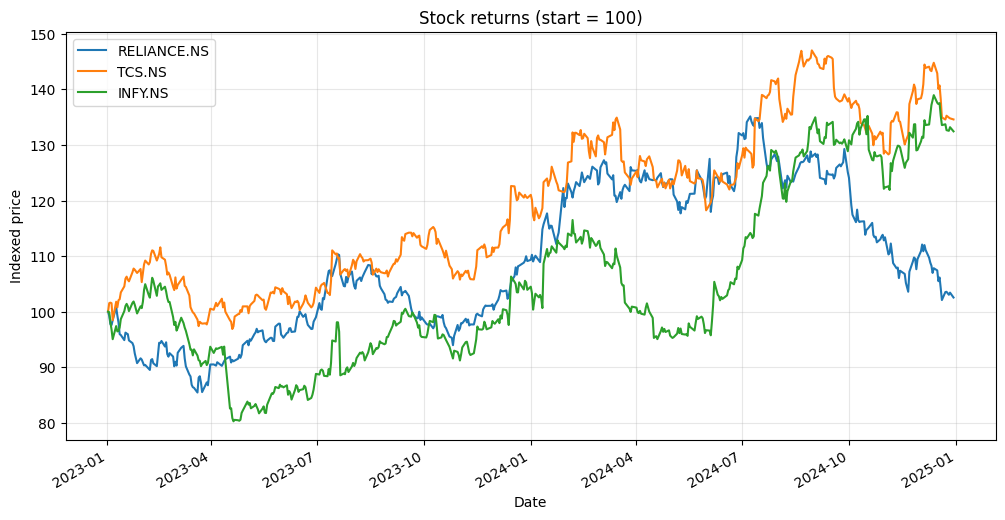

In [8]:
# Normalize prices so they all start at 100 — makes them comparable
normalized = close_prices/ close_prices.iloc[0] * 100 #integer location-->start every stock with 100
"""Why divide by prices.iloc[0] and multiply by 100? It rescales every stock so that day 1 = 100. Now you can see relative performance — which stock grew more, which lagged. If you plotted raw prices, Reliance at ₹2500 and Infosys at ₹1500 would look completely different even if they had the same returns."""

normalized.plot(figsize=(12, 6), title="Stock returns (start = 100)")
import matplotlib.pyplot as plt
plt.ylabel("Indexed price")
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
"""Analyzing Nifty 50 stocks"""
from backtester.data.loader import load_multiple_tickers, get_close_prices
from backtester.data.universes import NIFTY_50

# This will take a while the first time — it's downloading 45 stocks
data = load_multiple_tickers(NIFTY_50, "2014-01-01", "2025-12-31")
prices = get_close_prices(data)

print(f"Loaded {len(data)} stocks")
print(f"Price matrix shape: {prices.shape}")

Loading RELIANCE.NS ...
Loading RELIANCE.NS from cache
Loading TCS.NS ...
Loading TCS.NS from cache
Loading HDFCBANK.NS ...
Loading HDFCBANK.NS from cache
Loading INFY.NS ...
Loading INFY.NS from cache
Loading ICICIBANK.NS ...
Loading ICICIBANK.NS from cache
Loading HINDUNILVR.NS ...
Loading HINDUNILVR.NS from cache
Loading BHARTIARTL.NS ...
Loading BHARTIARTL.NS from cache
Loading ITC.NS ...
Loading ITC.NS from cache
Loading LT.NS ...
Loading LT.NS from cache
Loading KOTAKBANK.NS ...
Loading KOTAKBANK.NS from cache
Loading AXISBANK.NS ...
Loading AXISBANK.NS from cache
Loading SBIN.NS ...
Loading SBIN.NS from cache
Loading BAJFINANCE.NS ...
Loading BAJFINANCE.NS from cache
Loading ASIANPAINT.NS ...
Loading ASIANPAINT.NS from cache
Loading MARUTI.NS ...
Loading MARUTI.NS from cache
Loading HCLTECH.NS ...
Loading HCLTECH.NS from cache
Loading SUNPHARMA.NS ...
Loading SUNPHARMA.NS from cache
Loading TITAN.NS ...
Loading TITAN.NS from cache
Loading ULTRACEMCO.NS ...
Loading ULTRACEMCO.NS 

In [10]:
#Exploring the Nifty50 data

#missing data stocks
missing_per_stock = prices.isnull().sum()
print("Stocks with missing values:")
print(missing_per_stock.sort_values(ascending=False).head(10))

Stocks with missing values:
RELIANCE.NS      2469
TCS.NS           2469
INFY.NS          2469
HDFCLIFE.NS       954
SBILIFE.NS        922
HINDUNILVR.NS       0
ICICIBANK.NS        0
ITC.NS              0
LT.NS               0
KOTAKBANK.NS        0
dtype: int64


In [11]:
#find when each stock started trading
first_dates = prices.apply(lambda col: col.first_valid_index())
first_dates_sorted = first_dates.sort_values(ascending=False)

print("Most recently listed stocks (or recently added to data):")
print(first_dates_sorted.head(10))

Most recently listed stocks (or recently added to data):
RELIANCE.NS    2023-01-02
INFY.NS        2023-01-02
TCS.NS         2023-01-02
HDFCLIFE.NS    2017-11-17
SBILIFE.NS     2017-10-03
ICICIBANK.NS   2014-01-01
DRREDDY.NS     2014-01-01
JSWSTEEL.NS    2014-01-01
ONGC.NS        2014-01-01
TATASTEEL.NS   2014-01-01
dtype: datetime64[ms]


In [12]:
empty_stocks = prices.columns[prices.isna().all()]
print(f"Stocks with NO data at all: {len(empty_stocks)}")
print(list(empty_stocks))

#TATAMOTORS.NS stock was empty for all values, so I checked it and dropped it from NIFTY 50 list

Stocks with NO data at all: 0
[]


In [13]:
#MAKING CHART OF ALL STOCKS

#NORMALIZING THE PRICES

normalized = prices.apply(lambda col: col / col.dropna().iloc[0] * 100)
print(normalized)

            RELIANCE.NS  TCS.NS  HDFCBANK.NS  INFY.NS  ICICIBANK.NS  \
Date                                                                  
2014-01-01          NaN     NaN   100.000000      NaN    100.000000   
2014-01-02          NaN     NaN    98.774713      NaN     97.986682   
2014-01-03          NaN     NaN    99.691790      NaN     97.185027   
2014-01-06          NaN     NaN    99.481328      NaN     94.816440   
2014-01-07          NaN     NaN    99.887226      NaN     95.654542   
...                 ...     ...          ...      ...           ...   
2025-12-23          NaN     NaN   662.198919      NaN    767.834914   
2025-12-24          NaN     NaN   662.597618      NaN    766.032248   
2025-12-26          NaN     NaN   659.208857      NaN    760.736821   
2025-12-29          NaN     NaN   658.943098      NaN    756.737108   
2025-12-30          NaN     NaN   658.411540      NaN    756.286407   

            HINDUNILVR.NS  BHARTIARTL.NS      ITC.NS       LT.NS  \
Date    

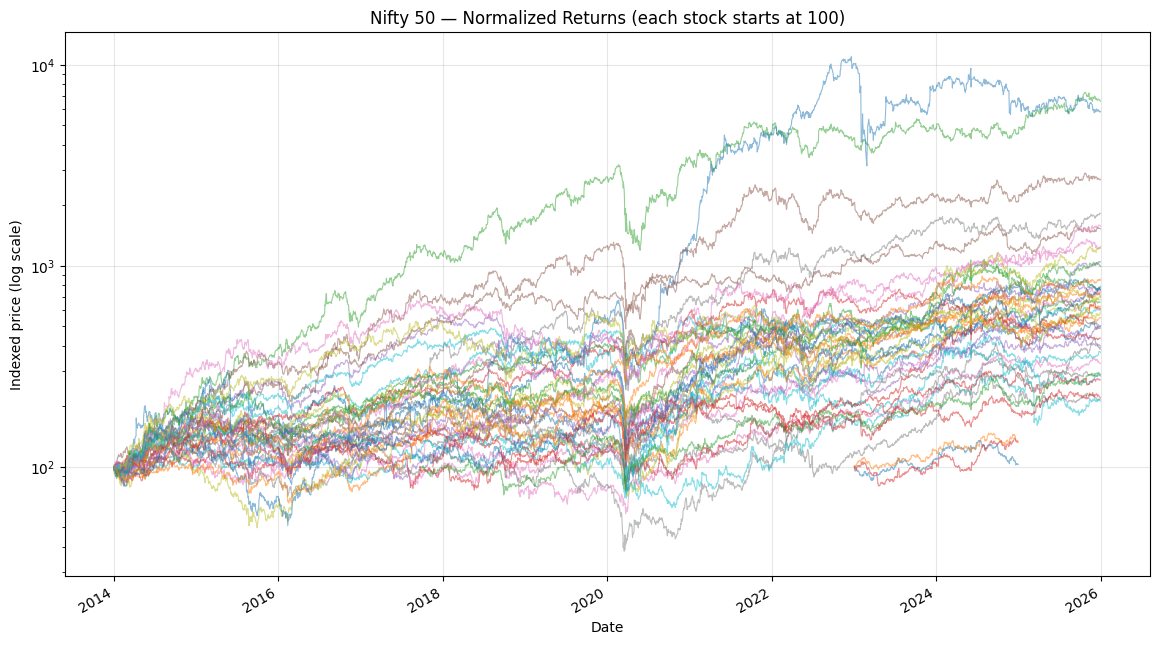

In [14]:
import matplotlib.pyplot as plt

normalized.plot(figsize=(14, 8), legend=False, alpha=0.5, linewidth=0.8)
plt.title("Nifty 50 — Normalized Returns (each stock starts at 100)")
plt.yscale("log")  #y-axis setting to log scale because of maintaining uniformity, as if some stock moved 100x and other just 10x, the disparity would not be veryy tremendous in plot.
plt.ylabel("Indexed price (log scale)")
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
#Analysing the winners and loosers

#divide latest price by first price. If a stock went from 500 to 2500, this gives 5.0. So you get the total growth multiple for each stock.
# - 1 — subtract 1. Going from 500 to 2500 is a 5.0x multiple, but the return is 4.0 (or 400%). Subtracting 1 converts a multiple to a return. (A stock that doesn't move has a multiple of 1.0 and a return of 0.)
# multiply by 100 for percentage
total_returns = (prices.iloc[-1]/prices.apply(lambda col: col.dropna().iloc[0]) - 1) *100

total_returns_sorted = total_returns.sort_values(ascending= False)

print("top 10 best performers:")
print(total_returns_sorted.head(10).round(0)) #round to zero decimal places

print("Bottom 10 worst performers:")
print(total_returns_sorted.tail(10).round(0))

top 10 best performers:
BAJFINANCE.NS    6481.0
ADANIENT.NS      5724.0
BAJAJFINSV.NS    2587.0
TITAN.NS         1715.0
EICHERMOT.NS     1465.0
BRITANNIA.NS     1425.0
JSWSTEEL.NS      1145.0
BPCL.NS          1124.0
MARUTI.NS         944.0
ADANIPORTS.NS     894.0
dtype: float64
Bottom 10 worst performers:
SBILIFE.NS       187.0
WIPRO.NS         186.0
ITC.NS           182.0
DRREDDY.NS       170.0
HDFCLIFE.NS      121.0
ONGC.NS          117.0
INDUSINDBK.NS    112.0
RELIANCE.NS        NaN
TCS.NS             NaN
INFY.NS            NaN
dtype: float64


In [16]:
returns = prices.pct_change()

#prices.pct_change() — pandas built-in. For each column, it calculates (today's price - yesterday's price) / yesterday's price. So if Reliance goes 100 → 102, that's a 2% return, stored as 0.02.
# The first row will be NaN — there's no "previous day" for the first day. That's expected.

In [17]:
#pick one stock-->our case "RELIANCE.NS"

reliance = returns["RELIANCE.NS"].dropna()

print(f"Reliance: {len(reliance)} trading days")
print(f"Mean daily return: {reliance.mean():.4%}")
print(f"Daily volatility:  {reliance.std():.4%}")
print(f"Best day:          {reliance.max():.2%}")
print(f"Worst day:         {reliance.min():.2%}")

Reliance: 489 trading days
Mean daily return: 0.0133%
Daily volatility:  1.2825%
Best day:          7.02%
Worst day:         -7.49%


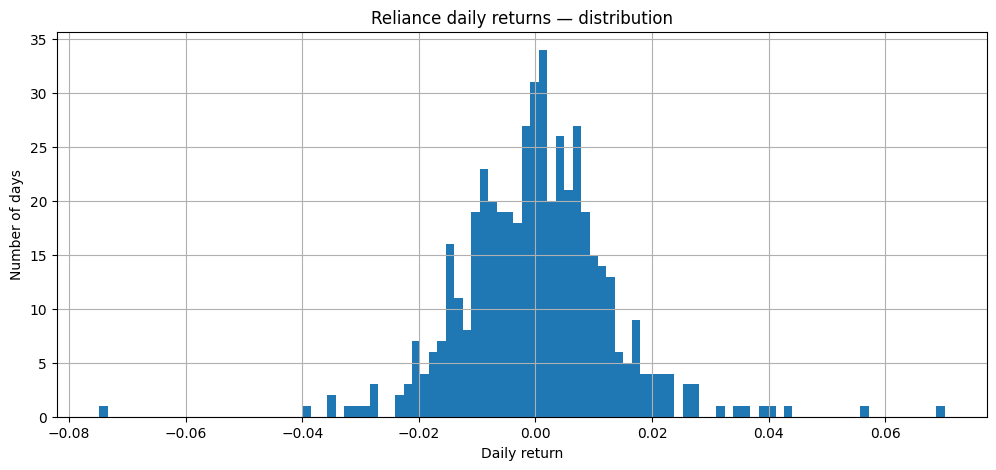

In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
reliance.hist(bins=100, ax=ax)
ax.set_title("Reliance daily returns — distribution")
ax.set_xlabel("Daily return")
ax.set_ylabel("Number of days")
plt.show()

In [19]:
extreme_threshold = 0.20

for ticker in returns.columns:
    extreme_days = returns[ticker][returns[ticker].abs() > extreme_threshold]
    if len(extreme_days) > 0:
        print(f"\n{ticker} had {len(extreme_days)} days with >20% moves:")
        print(extreme_days)


AXISBANK.NS had 1 days with >20% moves:
Date
2020-03-23   -0.279108
Name: AXISBANK.NS, dtype: float64

SBIN.NS had 1 days with >20% moves:
Date
2017-10-25    0.276872
Name: SBIN.NS, dtype: float64

BAJFINANCE.NS had 1 days with >20% moves:
Date
2020-03-23   -0.232308
Name: BAJFINANCE.NS, dtype: float64

ADANIENT.NS had 10 days with >20% moves:
Date
2014-04-10    0.228848
2015-06-03   -0.387493
2017-04-26   -0.209403
2018-09-06    0.209457
2019-05-20    0.273680
2020-08-25    0.236630
2023-02-01   -0.281970
2023-02-02   -0.266982
2023-02-08    0.200394
2024-11-21   -0.226068
Name: ADANIENT.NS, dtype: float64

BAJAJFINSV.NS had 1 days with >20% moves:
Date
2020-03-23   -0.258621
Name: BAJAJFINSV.NS, dtype: float64

ADANIPORTS.NS had 1 days with >20% moves:
Date
2024-06-04   -0.211497
Name: ADANIPORTS.NS, dtype: float64

INDUSINDBK.NS had 5 days with >20% moves:
Date
2020-03-18   -0.237276
2020-03-23   -0.235949
2020-03-26    0.446731
2020-04-07    0.225575
2025-03-11   -0.271571
Name: I

In [20]:
from backtester.data.loader import check_data_quality

check_data_quality(prices)

Shape: (2959, 44)
Date Range: 2014-01-01 to 2025-12-30
Missing values: 9283 (7.13%)
Stocks with no data: 0
Non-positive prices: 0
Duplicate dates: 0
